
# SupplyPrescript

## Notebook 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to analyze the cleaned supply chain dataset and uncover business insights that can improve logistics operations and support predictive and prescriptive analytics.

This notebook focuses on:

- Understanding shipment delays
- Sales and profit analysis
- Customer and market analysis
- Product category performance
- Shipping mode analysis
- Regional performance
- Feature relationships
- Business insights for model development

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
data = pd.read_csv("../data/processed/clean_supply_chain.csv")

data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Product Status,Shipping Mode,Lead_Time,Order_Month,Order_Year,Order_Weekday,Profit_Margin,High_Value_Order
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,Pacific Asia,Bekasi,Indonesia,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.75,0,Standard Class,3,1,2018,Wednesday,0.278413,1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,Pacific Asia,Bikaner,India,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,Smart watch,327.75,0,Standard Class,5,1,2018,Saturday,-0.760000,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,Consumer,CA,Fitness,Pacific Asia,Bikaner,India,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,Smart watch,327.75,0,Standard Class,4,1,2018,Saturday,-0.756003,1
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,Fitness,Pacific Asia,Townsville,Australia,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,Smart watch,327.75,0,Standard Class,3,1,2018,Saturday,0.069748,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,Fitness,Pacific Asia,Townsville,Australia,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,Smart watch,327.75,0,Standard Class,2,1,2018,Saturday,0.409489,1


In [3]:
data.shape

(180519, 37)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Name                  180519 non-null  str    
 8   Customer City                  180519 non-null  str    
 9   Customer Country               180519 non-null  str    
 10  Customer Segment               180519 non-null  str    
 11  Customer State                 180519 non-null  str    
 12  Department Name                180519 non

In [5]:
data.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Product Status,Lead_Time,Order_Month,Order_Year,Profit_Margin,High_Value_Order
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.0,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,20.664741,0.101668,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,141.232550,0.0,3.471856,6.235449,2015.971150,0.108326,0.487699
std,1.623722,1.374449,104.433526,120.043670,0.497664,21.800901,0.070415,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,139.732492,0.0,1.670471,3.403571,0.829429,0.420594,0.499850
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,9.990000,0.0,0.000000,1.000000,2015.000000,-2.750000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,50.000000,0.0,2.000000,3.000000,2015.000000,0.062240,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,14.000000,0.100000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59.990002,0.0,3.000000,6.000000,2016.000000,0.242512,0.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,29.990000,0.160000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,199.990005,0.0,5.000000,9.000000,2017.000000,0.336014,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,500.000000,0.250000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,1999.989990,0.0,6.000000,12.000000,2018.000000,0.500443,1.000000


## Target Variable Analysis

The primary prediction target is **Late Delivery Risk**.

Understanding whether the dataset is balanced is important before training a machine learning model.

In [6]:
data["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

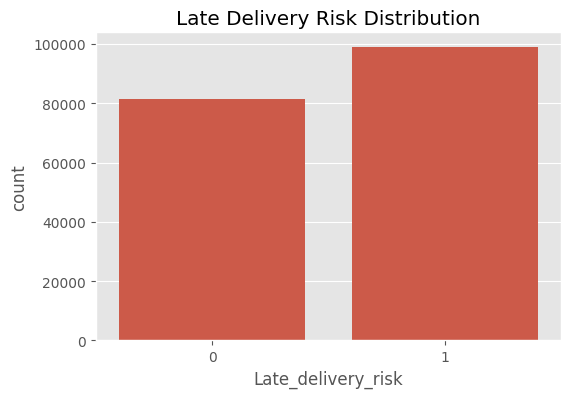

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Late_delivery_risk",
    data=data
)

plt.title("Late Delivery Risk Distribution")

plt.show()

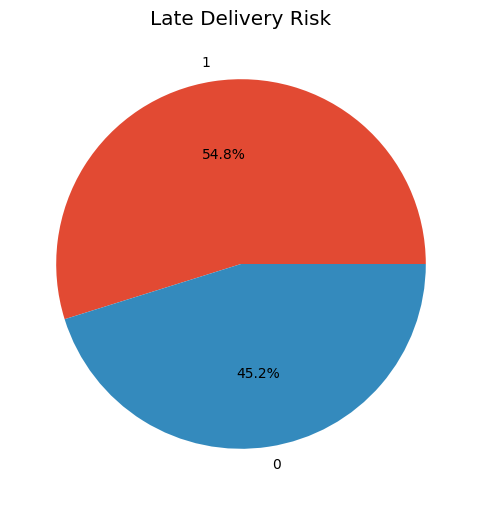

In [8]:
data["Late_delivery_risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Late Delivery Risk")
plt.show()

### Observation

Slightly more than half of the orders were at risk of late delivery.
The dataset is fairly balanced, with only a slight difference between both the classes.

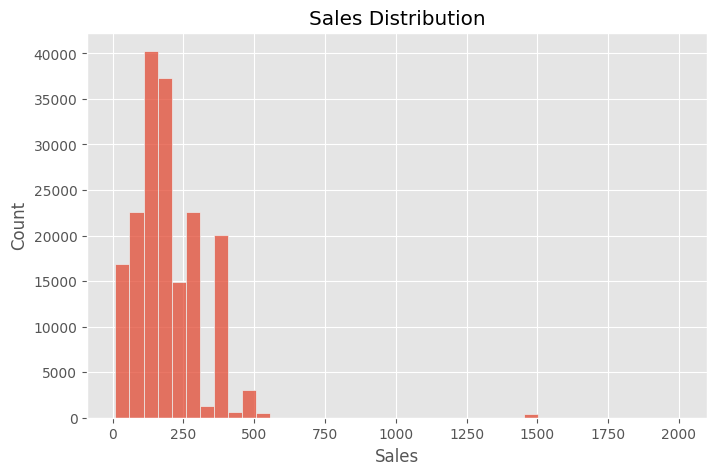

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["Sales"],
    bins=40
)

plt.title("Sales Distribution")

plt.show()

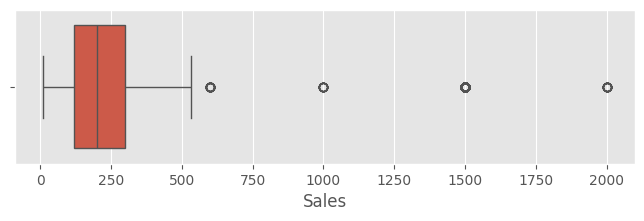

In [10]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=data["Sales"]
)

plt.show()

### Observation

The Sales variable is positively skewed, with most transactions falling between approximately 150 and 300. Several high-value outliers (above 600) are present, indicating a small number of large orders. These outliers are likely genuine business transactions and may have a significant impact on revenue and delivery decisions, so they should be investigated rather than removed blindly.

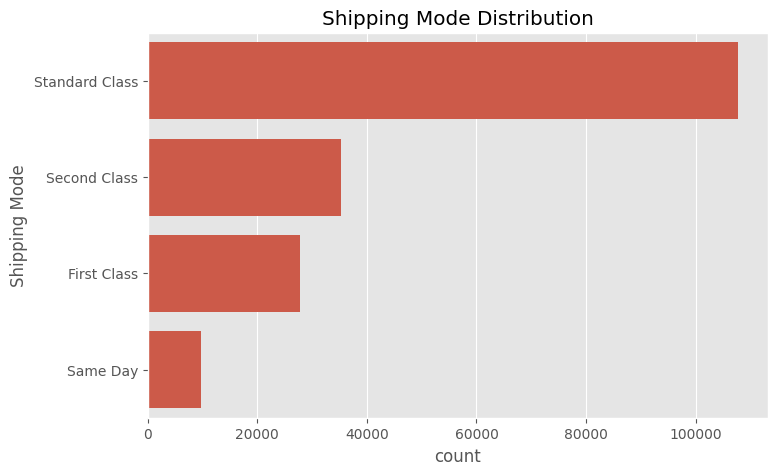

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Shipping Mode",
    data=data,
    order=data["Shipping Mode"].value_counts().index
)

plt.title("Shipping Mode Distribution")

plt.show()

In [12]:
data.groupby("Shipping Mode")["Sales"].mean().sort_values()

Shipping Mode
Same Day          199.499698
Second Class      202.903363
First Class       204.011281
Standard Class    204.380354
Name: Sales, dtype: float64

## Observation

Standard class is the most frequently used shipping mode and has the highest average sales amongst all the other shipping methods.

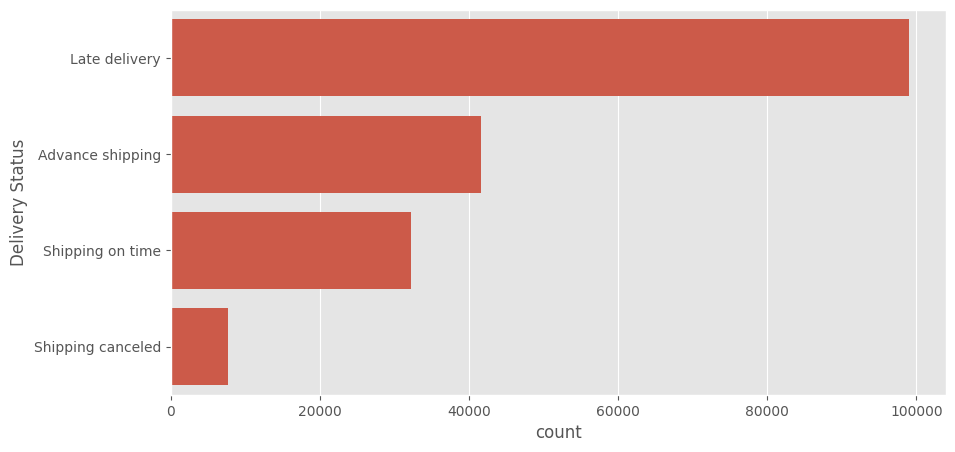

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="Delivery Status",
    data=data,
    order=data["Delivery Status"].value_counts().index
)

plt.show()

## Observation

Maximum orders are delivered late as compared to their expected time of arrival.

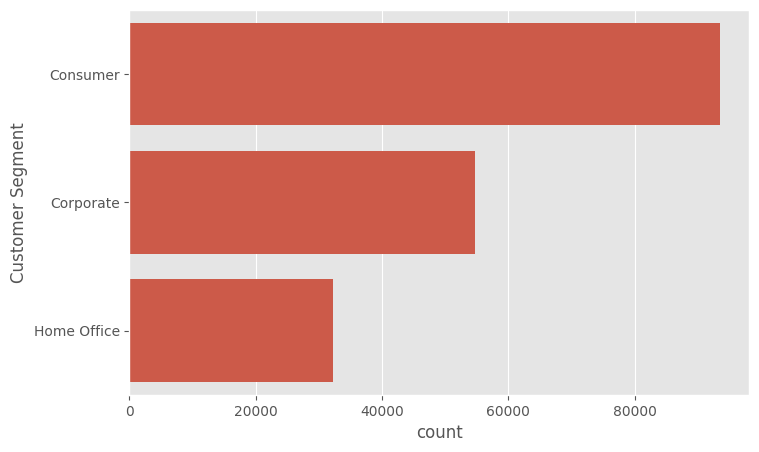

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Customer Segment",
    data=data,
    order=data["Customer Segment"].value_counts().index
)

plt.show()

In [15]:
data.groupby("Customer Segment")["Sales"].sum().sort_values(ascending=False)

Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64

## Observation

Consumers contribute the highest revenue.

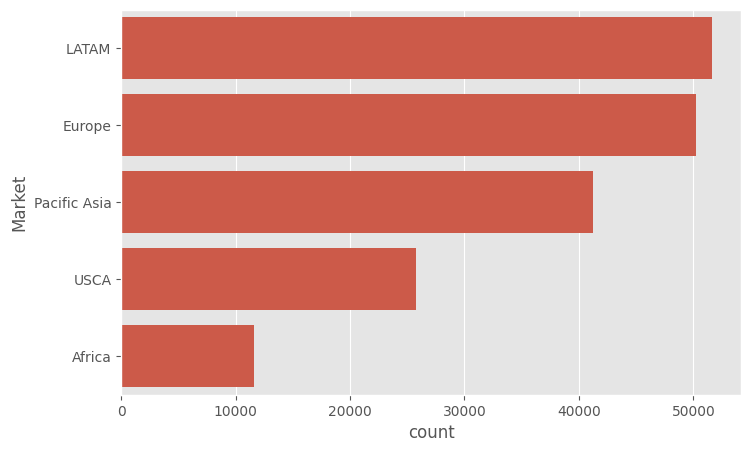

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Market",
    data=data,
    order=data["Market"].value_counts().index
)

plt.show()

In [17]:
data.groupby("Market")["Sales"].sum().sort_values(ascending=False)

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64

## Observation

While the largest market is in LATAM, the European market provides the highest revenue.


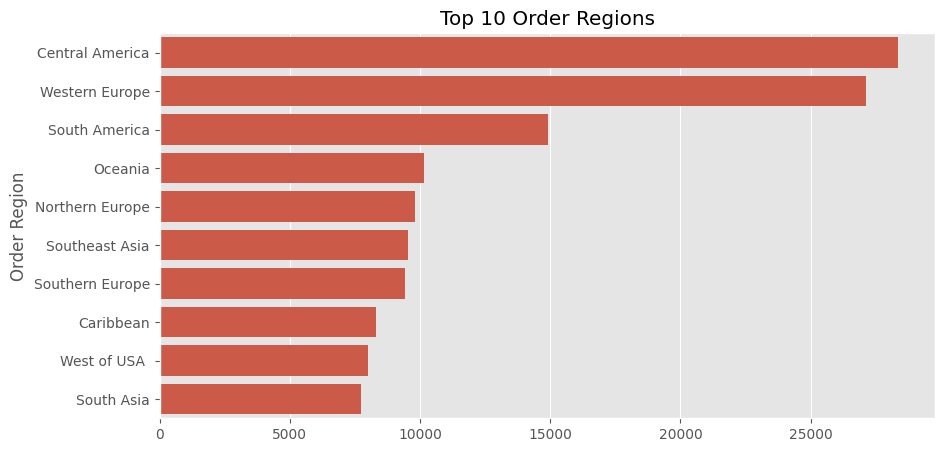

In [18]:
top_regions = data["Order Region"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index
)

plt.title("Top 10 Order Regions")

plt.show()

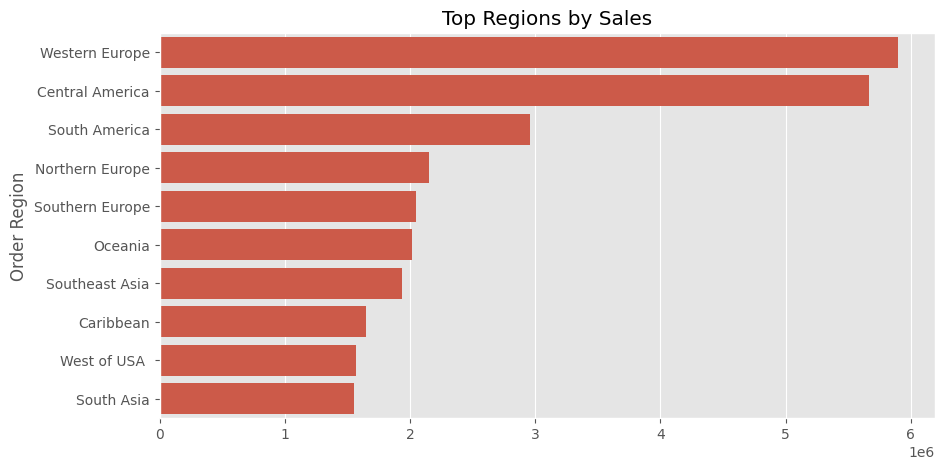

In [19]:
region_sales = (
    data.groupby("Order Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index
)

plt.title("Top Regions by Sales")

plt.show()

## Observation

The region with the highest number of orders is Central America whereas the region with the highest sales is Western Europe, which is 2nd in terms of number of orders.

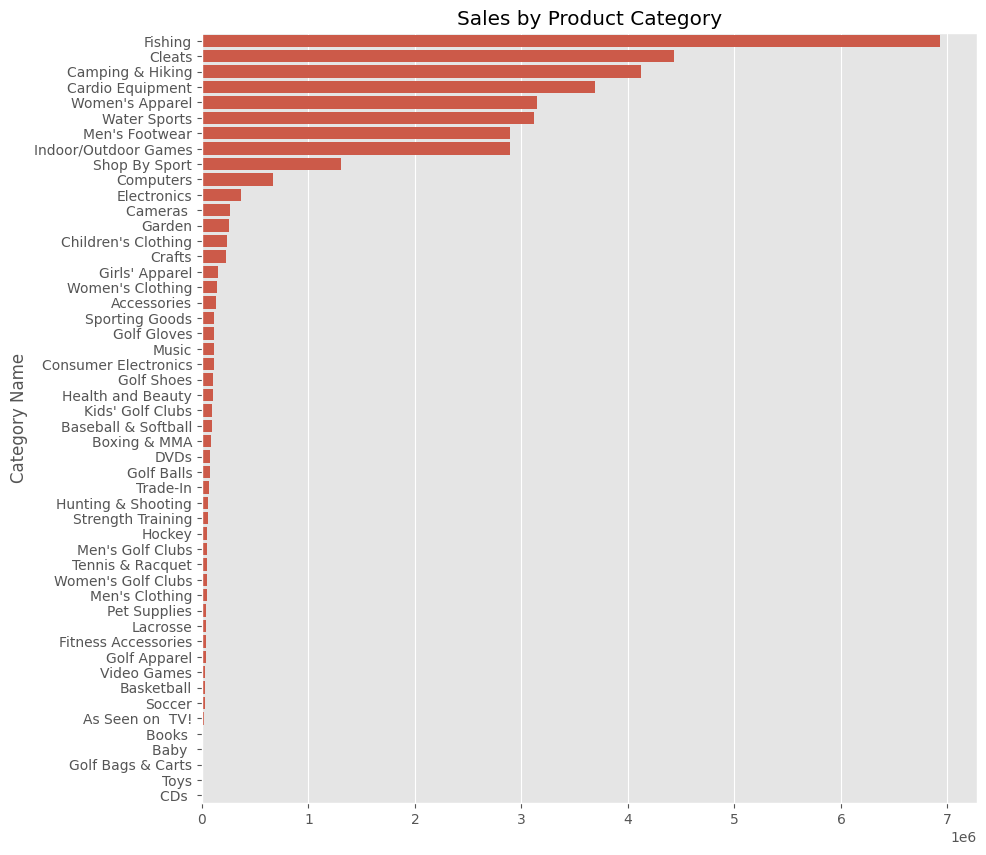

In [21]:
category_sales = (
    data.groupby("Category Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Sales by Product Category")

plt.show()

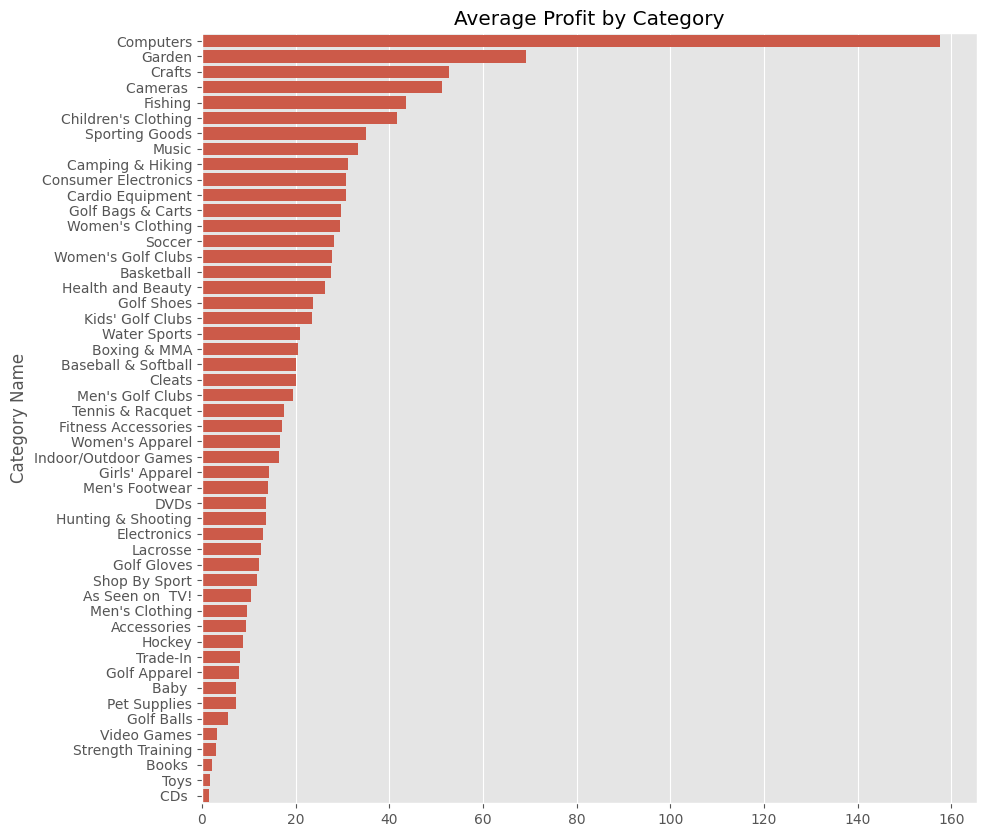

In [23]:
category_profit = (
    data.groupby("Category Name")["Benefit per order"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index
)

plt.title("Average Profit by Category")

plt.show()

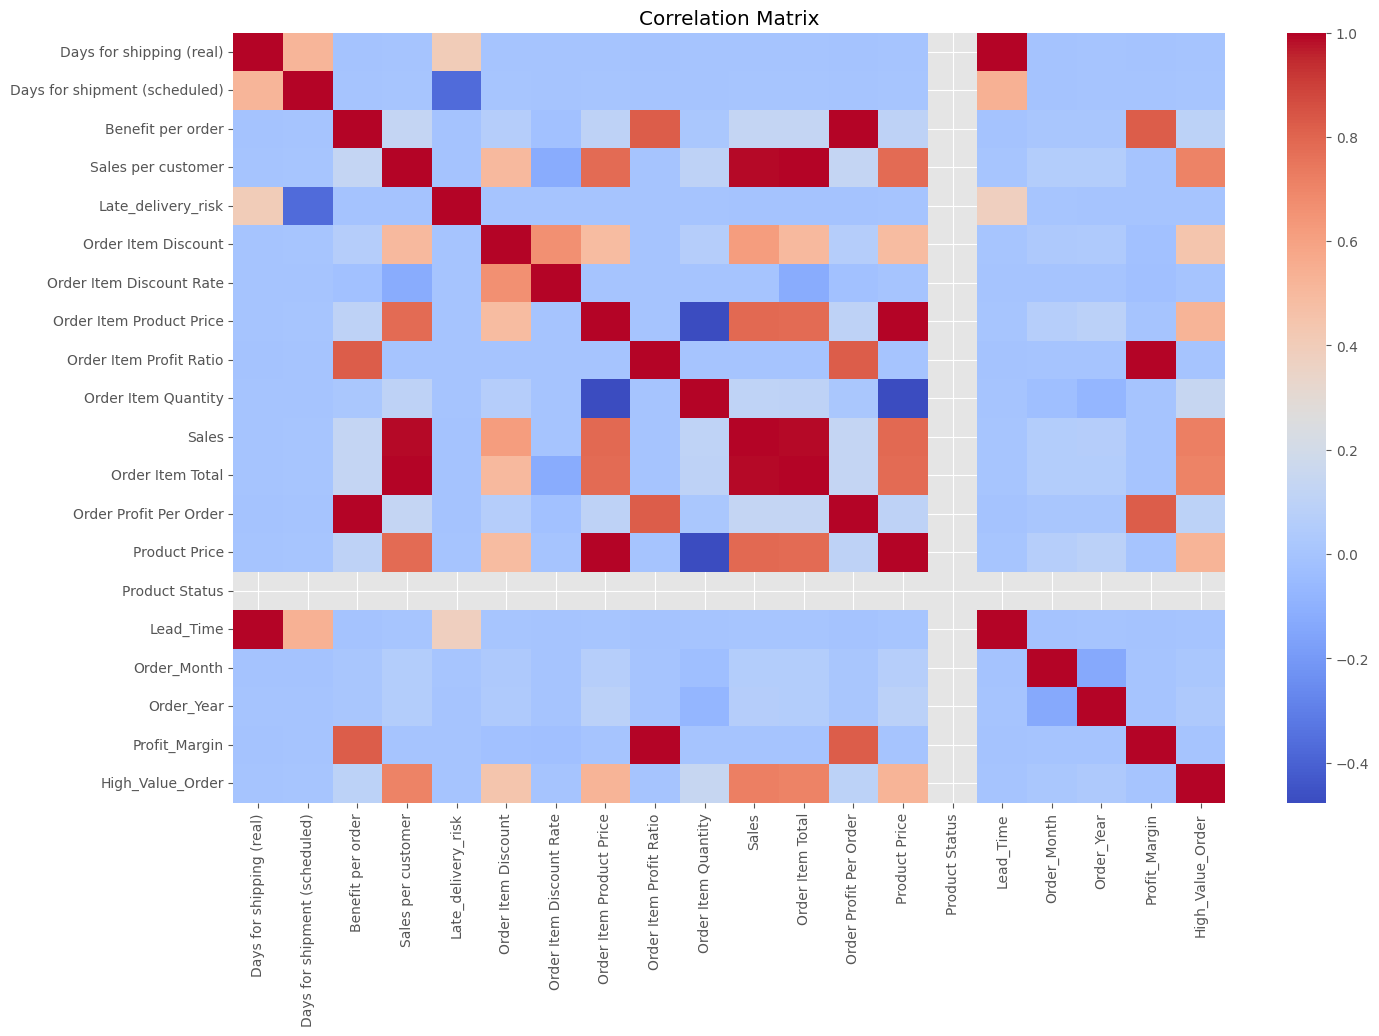

In [24]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(16,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
corr_matrix = data.corr(numeric_only=True)

corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs.sort_values(kind="quicksort")

corr_pairs.tail(20)

Product Status    Order Item Discount        NaN
                  Order Item Discount Rate   NaN
                  Order Item Product Price   NaN
                  Order Item Profit Ratio    NaN
                  Order Item Quantity        NaN
                  Sales                      NaN
                  Order Item Total           NaN
                  Order Profit Per Order     NaN
                  Product Price              NaN
                  Product Status             NaN
                  Lead_Time                  NaN
                  Order_Month                NaN
                  Order_Year                 NaN
                  Profit_Margin              NaN
                  High_Value_Order           NaN
Lead_Time         Product Status             NaN
Order_Month       Product Status             NaN
Order_Year        Product Status             NaN
Profit_Margin     Product Status             NaN
High_Value_Order  Product Status             NaN
dtype: float64

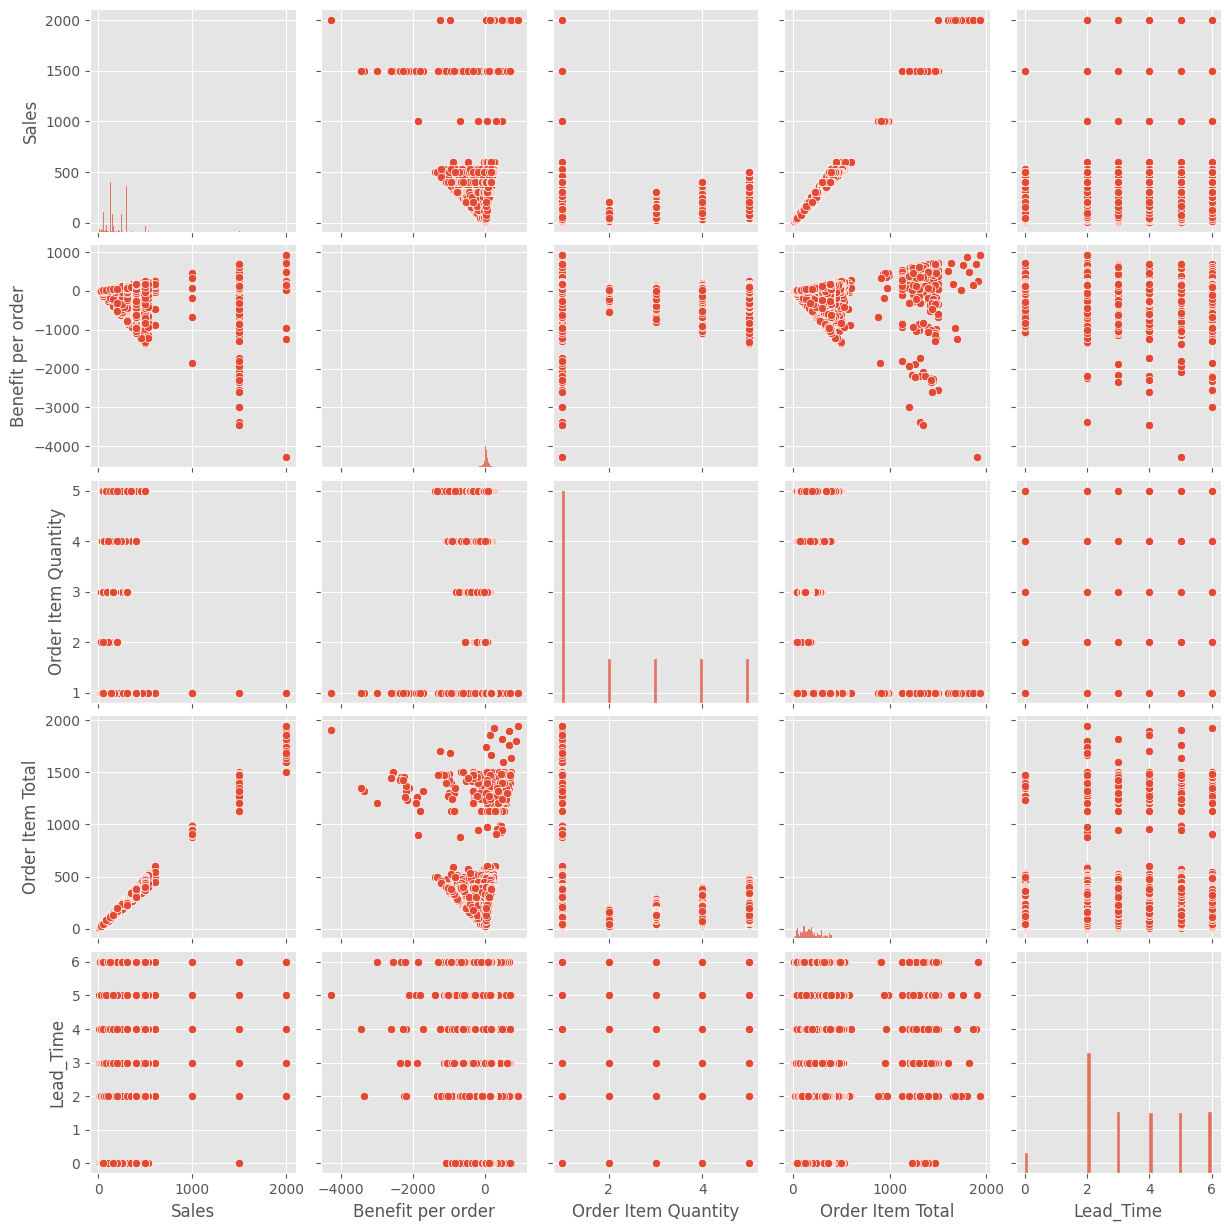

In [26]:
selected = [
    "Sales",
    "Benefit per order",
    "Order Item Quantity",
    "Order Item Total",
    "Lead_Time"
]

sns.pairplot(data[selected])

plt.show()

Which shipping mode has the highest average profit?

In [27]:
data.groupby("Shipping Mode")["Benefit per order"].mean().sort_values(ascending=False)

Shipping Mode
First Class       23.122238
Standard Class    21.999169
Second Class      21.305889
Same Day          20.850203
Name: Benefit per order, dtype: float64

Which market has the highest sales?

In [28]:
data.groupby("Market")["Sales"].sum().sort_values(ascending=False)

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64

Which customer segment buys the most?

In [29]:
data.groupby("Customer Segment")["Sales"].sum().sort_values(ascending=False)

Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64

Which region has the highest delay risk?

In [30]:
(
    data.groupby("Order Region")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
)

Order Region
Central Africa     0.579606
South Asia         0.562670
East Africa        0.559395
Western Europe     0.558486
South of  USA      0.557726
Eastern Europe     0.556633
East of USA        0.556616
Southeast Asia     0.555299
Central Asia       0.553345
West Asia          0.552837
US Center          0.552404
Central America    0.547546
North Africa       0.545173
Southern Europe    0.543845
Eastern Asia       0.543269
South America      0.543087
Northern Europe    0.540441
Oceania            0.540205
West of USA        0.539597
Southern Africa    0.533276
Caribbean          0.530777
West Africa        0.528409
Canada             0.488008
Name: Late_delivery_risk, dtype: float64

Which product category generates the highest revenue?

In [31]:
data.groupby("Category Name")["Sales"].sum().sort_values(ascending=False)

Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Music                   1.131221e+05
Consumer Electronics    1.089913e+05
Golf Shoes              1.079980e+05
Health and Beauty       1.060805e+05
Kids' Golf Clubs        9.879758e+04
Baseball & Softball     9.405715e+04
Boxing & MMA            

# Key Business Insights

- The dataset contains approximately 180519 records after preprocessing.
- The target variable appears balanced.
- Standard Class is the most frequently used shipping method.
- The highest revenue comes from European market.
- The most profitable product category is Fishing.
- Certain regions experience higher delivery delays than others.
- Sales contain several high-value outliers.
- These findings will guide feature selection and predictive modeling in the next notebook.

In [32]:
data.to_csv("../data/processed/eda_dataset.csv", index=False)